# 04 · Fine-tuning Cellpose-SAM

Fine-tunes cpsam on hand-annotated patches from `data/annotations/`.
Requires at least 5 annotated patches; all 9 (3×3) is ideal.

**Prerequisites:**
- `01_tiling_preprocessing.ipynb` — patch export
- Cellpose GUI annotation — after saving, each patch has a `*_seg.npy` file
  in `data/annotations/images/`

**Outputs:**
- `models/finetuned/cpsam_finetuned` — fine-tuned weights
- `figures/qc/04_annotation_qc.png` — annotation overview (verify before training)
- `figures/qc/04_val_comparison.png` — base cpsam vs fine-tuned on held-out patches

**Environment:** `cellpose`

In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path
from cellpose import models, train, io, metrics

In [ ]:
PROJECT_ROOT   = Path('/Users/alicehong/projects/cellpose-biosensor')
ANNOT_IMG_DIR  = PROJECT_ROOT / 'data/annotations/images'
ANNOT_MSK_DIR  = PROJECT_ROOT / 'data/annotations/masks'
MODEL_SAVE_DIR = PROJECT_ROOT / 'models/finetuned'
FIG_DIR        = PROJECT_ROOT / 'figures/qc'

MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

PIXEL_SIZE_UM = 0.035
DIAMETER_PX   = 1.5 / PIXEL_SIZE_UM   # 42.9 px

# ── Training hyperparameters (matching official Cellpose-SAM colab) ───────────
N_EPOCHS      = 100    # increase to 200 if val loss is still falling at 100
LEARNING_RATE = 1e-5   # conservative — avoids overwriting SAM backbone features
WEIGHT_DECAY  = 0.1    # as per official colab
BATCH_SIZE    = 1      # SAM is memory-heavy; 1 is standard
VAL_FRAC      = 0.2    # Fraction to be used for validation (rest is training)
MIN_MASKS     = 3
MODEL_NAME    = 'cpsam_finetuned'

## Load annotations

Looks for masks in two places (in order):
1. `data/annotations/images/*_seg.npy` — Cellpose GUI native format
2. `data/annotations/masks/*.tif` — manual TIFF export

In [3]:
def load_mask_for_patch(patch_path: Path) -> np.ndarray | None:
    """Load mask for a patch. Returns None if no mask found."""
    # Priority 1: Cellpose GUI seg.npy
    seg_path = patch_path.parent / (patch_path.stem + '_seg.npy')
    if seg_path.exists():
        dat = np.load(seg_path, allow_pickle=True).item()
        return dat['masks'].astype(np.int32)
    # Priority 2: TIFF mask in separate directory
    tif_path = ANNOT_MSK_DIR / patch_path.name
    if tif_path.exists():
        return tifffile.imread(str(tif_path)).astype(np.int32)
    return None

patch_paths = sorted(ANNOT_IMG_DIR.glob('patch_r*.tif'))
print(f'Found {len(patch_paths)} patches in {ANNOT_IMG_DIR}')

pairs = []
skipped = []
for pp in patch_paths:
    img  = tifffile.imread(str(pp)).astype(np.float32)
    mask = load_mask_for_patch(pp)
    if mask is None:
        skipped.append(pp.name)
        continue
    n_cells = mask.max()
    if n_cells < MIN_MASKS:
        skipped.append(f'{pp.name} ({n_cells} cells < {MIN_MASKS})')
        continue
    pairs.append({'name': pp.stem, 'img': img, 'mask': mask, 'n_cells': n_cells})

print(f'Loaded {len(pairs)} annotated pairs')
if skipped:
    print(f'Skipped {len(skipped)}: {skipped}')
assert len(pairs) >= 3, (
    f'Only {len(pairs)} annotated patches found. '
    'Annotate more patches before fine-tuning (target: all 9).')

Found 9 patches in /Users/alicehong/projects/cellpose-biosensor/data/annotations/images
Loaded 9 annotated pairs


## Annotation QC

Verify that masks look correct before committing to training.
Red outlines = cell boundaries from your annotations.

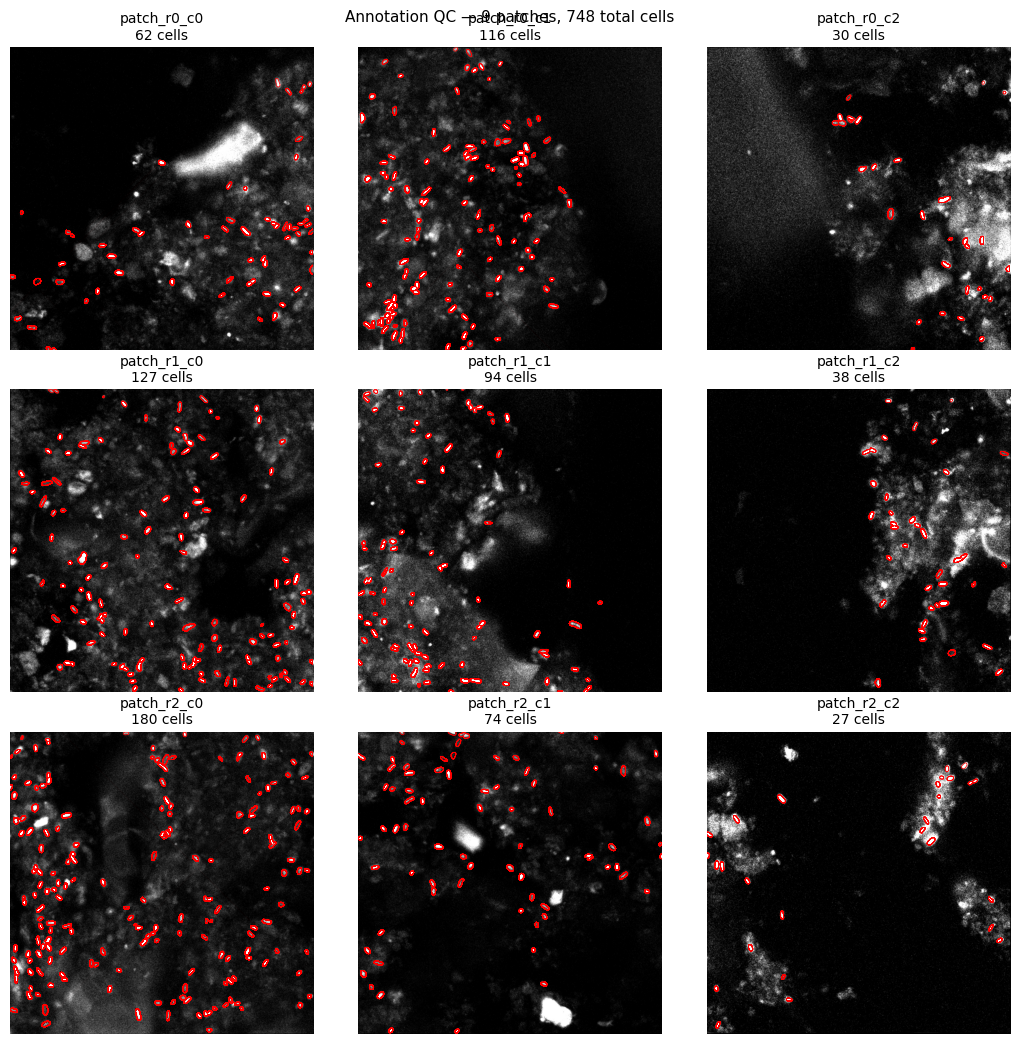

Saved → /Users/alicehong/projects/cellpose-biosensor/figures/qc/04_annotation_qc.svg


In [16]:
n = len(pairs)
ncols = min(n, 3)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5), facecolor='white')
axes = np.array(axes).reshape(nrows, ncols)

## Below is just to visualize the images and masks for QC, not used for trainig!
def disp_norm(arr):
    """Percentile stretch for display — works on any dtype/range."""
    lo, hi = np.percentile(arr, 1), np.percentile(arr, 99)
    return np.clip((arr.astype(float) - lo) / (hi - lo + 1e-8), 0, 1)

for i, p in enumerate(pairs):
    ax = axes[i // ncols][i % ncols]
    ax.set_facecolor('white')
    ax.imshow(disp_norm(p['img']), cmap='gray', vmin=0, vmax=1)
    if p['mask'].max() > 0:
        ax.contour(p['mask'],
                   levels=np.arange(0.5, p['mask'].max() + 0.5),
                   colors='red', linewidths=0.5)
    ax.set_title(f"{p['name']}\n{p['n_cells']} cells", 
                 color='black', fontsize=10)
    ax.axis('off')

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

fig.suptitle(f'Annotation QC — {n} patches, {sum(p["n_cells"] for p in pairs)} total cells',
             color='black', fontsize=11)
plt.tight_layout(pad=0.3)
plt.savefig(FIG_DIR / '04_annotation_qc.svg', dpi=100,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {FIG_DIR}/04_annotation_qc.svg')

## Train / validation split

This notebook creates only a **train / validation** split from the annotated
patches loaded above. It does **not** create a separate held-out test set.
The validation tiles are used both during training and later for the base-vs-
fine-tuned comparison, so results here should be treated as validation results,
not final test performance.

In [5]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(pairs))
n_val = max(1, round(len(pairs) * VAL_FRAC))

val_idx   = idx[:n_val]
train_idx = idx[n_val:]

train_imgs   = [pairs[i]['img']  for i in train_idx]
train_masks  = [pairs[i]['mask'] for i in train_idx]
val_imgs     = [pairs[i]['img']  for i in val_idx]
val_masks    = [pairs[i]['mask'] for i in val_idx]

print(f'Train: {len(train_imgs)} tiles  |  Val: {len(val_imgs)} tiles')
print(f'Train: {[pairs[i]["name"] for i in train_idx]}')
print(f'Val:   {[pairs[i]["name"] for i in val_idx]}')

Train: 7 tiles  |  Val: 2 tiles
Train: ['patch_r2_c1', 'patch_r0_c2', 'patch_r1_c1', 'patch_r2_c0', 'patch_r0_c1', 'patch_r1_c2', 'patch_r2_c2']
Val:   ['patch_r1_c0', 'patch_r0_c0']


## Fine-tune

Uses `train.train_seg(model.net, ...)` (Cellpose 4.x API)
This passes the underlying network directly, matching the published Cellpose-SAM colab.
Returns a 3-tuple: `(model_path, train_losses, test_losses)`.

In [6]:
print('Loading cpsam base model...')
model = models.CellposeModel(gpu=True)

print(f'Training on {len(train_imgs)} patches  |  val on {len(val_imgs)} patches')
print(f'lr={LEARNING_RATE}  wd={WEIGHT_DECAY}  batch={BATCH_SIZE}  epochs={N_EPOCHS}')
print(f'nimg_per_epoch={max(2, len(train_imgs))}')
print(f'Saving to: {MODEL_SAVE_DIR}\n')

saved_path, train_losses, test_losses = train.train_seg(
    model.net,
    train_data=train_imgs,
    train_labels=train_masks,
    # In the Cellpose API these arguments are named `test_*`, but in this
    # notebook they are being used as the validation split, not a true test set.
    test_data=val_imgs,
    test_labels=val_masks,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    nimg_per_epoch=max(2, len(train_imgs)),
    model_name=MODEL_NAME,
    save_path=str(MODEL_SAVE_DIR),
)

saved_path = Path(saved_path)
print(f'\nModel saved → {saved_path}')

path_file = MODEL_SAVE_DIR / 'latest_model_path.txt'
path_file.write_text(str(saved_path))
print(f'Path recorded → {path_file}')

Loading cpsam base model...
Training on 7 patches  |  val on 2 patches
lr=1e-05  wd=0.1  batch=1  epochs=100
nimg_per_epoch=7
Saving to: /Users/alicehong/projects/cellpose-biosensor/models/finetuned



100%|██████████| 2/2 [00:00<00:00, 46.58it/s]
/Users/alicehong/miniforge3/envs/cellpose/lib/python3.10/site-packages/cellpose/train.py:463: UserWarning: In MPS autocast, but the target dtype is not supported. Disabling autocast.
MPS Autocast only supports dtypes of torch.bfloat16, torch.float16 currently.
  with torch.autocast(device_type=device.type, dtype=net.dtype):
/Users/alicehong/miniforge3/envs/cellpose/lib/python3.10/site-packages/cellpose/train.py:508: UserWarning: In MPS autocast, but the target dtype is not supported. Disabling autocast.
MPS Autocast only supports dtypes of torch.bfloat16, torch.float16 currently.
  with torch.autocast(device_type=device.type, dtype=net.dtype):



Model saved → /Users/alicehong/projects/cellpose-biosensor/models/finetuned/models/cpsam_finetuned
Path recorded → /Users/alicehong/projects/cellpose-biosensor/models/finetuned/latest_model_path.txt


## Training curves

Loss values come from the `train_seg` return tuple — no model attribute needed.

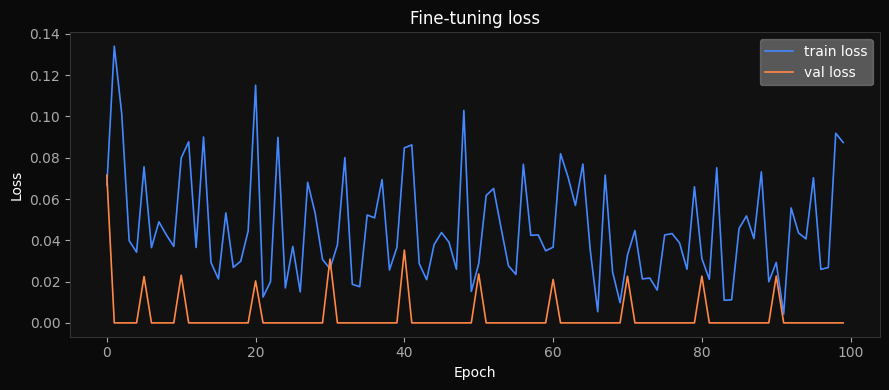

Saved → /Users/alicehong/projects/cellpose-biosensor/figures/qc/04_training_curves.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 4), facecolor='#0a0a0a')
ax.set_facecolor('#111')

# Cellpose may return NumPy arrays here; check length explicitly rather than
# using `if train_losses`, which is ambiguous for multi-element arrays.
if train_losses is not None and len(train_losses) > 0:
    ax.plot(train_losses, color='#4488ff', lw=1.2, label='train loss')
if test_losses is not None and len(test_losses) > 0:
    ax.plot(test_losses, color='#ff8844', lw=1.2, label='val loss')

ax.set_xlabel('Epoch', color='white')
ax.set_ylabel('Loss', color='white')
ax.set_title('Fine-tuning loss', color='white')
ax.tick_params(colors='#aaa')
ax.legend(framealpha=0.3, labelcolor='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333')

plt.tight_layout()
plt.savefig(FIG_DIR / '04_training_curves.png', dpi=100,
            bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print(f'Saved → {FIG_DIR}/04_training_curves.png')

## Validation: base cpsam vs fine-tuned

Runs both models on held-out patches, computes average precision at IoU 0.5
(same metric as the official Cellpose-SAM paper), and shows a visual comparison.

In [18]:
model_ft   = models.CellposeModel(gpu=True, pretrained_model=str(saved_path))
model_base = models.CellposeModel(gpu=True)

# normalize=True (default) — Cellpose normalises internally, matching train_seg behaviour
eval_kwargs = dict(diameter=DIAMETER_PX, channels=[0, 0],
                   flow_threshold=0.4, cellprob_threshold=0.0)

masks_base_list, masks_ft_list = [], []
for img in val_imgs:
    masks_base_list.append(model_base.eval(img, **eval_kwargs)[0])
    masks_ft_list.append(model_ft.eval(img, **eval_kwargs)[0])

# ── Average precision at IoU 0.5 ─────────────────────────────────────────────
ap_base = metrics.average_precision(val_masks, masks_base_list)[0]
ap_ft   = metrics.average_precision(val_masks, masks_ft_list)[0]
print(f'Average precision @ IoU 0.5:')
print(f'  Base cpsam:  {ap_base[:, 0].mean():.3f}')
print(f'  Fine-tuned:  {ap_ft[:, 0].mean():.3f}')

# ── Visual comparison — full validation tiles ──────────────────────────────────
n_val = len(val_imgs)
fig, axes = plt.subplots(n_val, 3, figsize=(12, n_val * 4.5), facecolor='black')
if n_val == 1:
    axes = axes[np.newaxis, :]

axes[0][0].set_title('Ground truth', color='gold',    fontsize=9)
axes[0][1].set_title('Base cpsam',   color='#aaaaff', fontsize=9)
axes[0][2].set_title('Fine-tuned',   color='#88ff88', fontsize=9)

for row, (img, gt, m_base, m_ft) in enumerate(
        zip(val_imgs, val_masks, masks_base_list, masks_ft_list)):
    img_disp = disp_norm(img)

    for col, (mask, color) in enumerate([
        (gt,     'gold'),
        (m_base, '#aaaaff'),
        (m_ft,   '#88ff88'),
    ]):
        ax = axes[row][col]
        ax.set_facecolor('black')
        ax.imshow(img_disp, cmap='gray', vmin=0, vmax=1)
        if mask.max() > 0:
            ax.contour(mask, levels=np.arange(0.5, mask.max() + 0.5),
                       colors=color, linewidths=0.6)
        ax.set_title(f'{mask.max()} cells total', color=color, fontsize=7)
        ax.axis('off')

fig.suptitle(
    f'Validation (full tiles shown)\n'
    f'AP@0.5 — base: {ap_base[:,0].mean():.3f}  fine-tuned: {ap_ft[:,0].mean():.3f}',
    color='white', fontsize=10)
plt.tight_layout(pad=0.3)
plt.savefig(FIG_DIR / '04_val_comparison.png', dpi=120,
            bbox_inches='tight', facecolor='black')
plt.show()
print(f'Saved → {FIG_DIR}/04_val_comparison.png')

pretrained model /Users/alicehong/.cellpose/models/cpsam not found, using default model
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


KeyboardInterrupt: 

## Summary

**AP@IoU 0.5 > base cpsam** → proceed to `05_segmentation_pipeline.ipynb`.

**AP@IoU 0.5 ≤ base cpsam** — things to try:
- Annotate more patches (priority: regions where base cpsam performs worst)
- Increase `N_EPOCHS` to 200 if val loss was still falling
- Check annotation quality — accidental mis-labels hurt more than fewer clean labels

Fine-tuned model path recorded in `models/finetuned/latest_model_path.txt`.

## Training curves (script-style)

In [ ]:
from aquarel import load_theme

#AQUAREL_THEME = 'boxy_light'

#theme = load_theme(AQUAREL_THEME)
#theme.apply()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='train')
ax.plot(test_losses,  label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Fine-tuning loss')
ax.legend()
fig.tight_layout()
plt.savefig(FIG_DIR / '04_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
plt.rcdefaults()

## Validation comparison (script-style)

IndexError: list index out of range

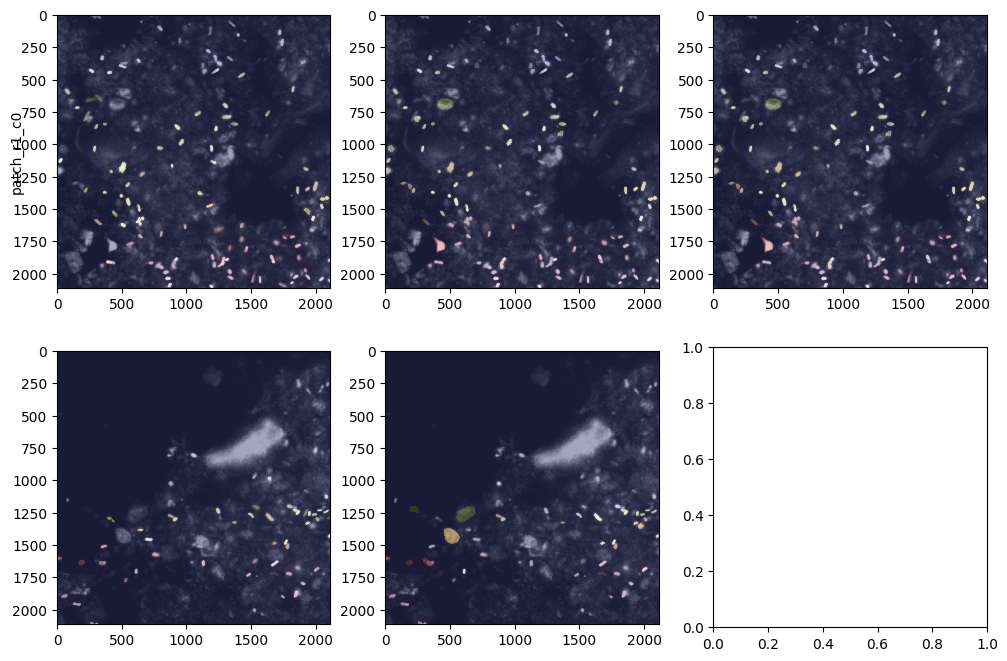

In [22]:
val_pairs = [pairs[i] for i in val_idx]

def norm(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-6), 0, 1)

def show_mask(ax, img_norm, mask):
    ax.imshow(img_norm, cmap='gray', vmin=0, vmax=1)
    if mask.max() > 0:
        ax.imshow(mask, cmap='tab20b', alpha=0.45, interpolation='nearest')

n_show = len(val_imgs)
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    img_n = norm(val_imgs[i])
    show_mask(axes[i, 0], img_n, val_masks[i])
    show_mask(axes[i, 1], img_n, masks_base_list[i])
    show_mask(axes[i, 2], img_n, masks_ft_list[i])
    axes[i, 0].text(-0.12, 0.5, val_pairs[i]['name'],
                    transform=axes[i, 0].transAxes,
                    rotation=90, va='center', ha='right', fontsize=10, clip_on=False)

axes[0, 0].set_title('ground truth')
axes[0, 1].set_title('base cpsam')
axes[0, 2].set_title('fine-tuned')
for ax in axes.flat:
    ax.axis('off')

fig.tight_layout()
fig.subplots_adjust(left=0.16)
plt.savefig(FIG_DIR / '04_val_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## AP bars and cell counts (script-style)

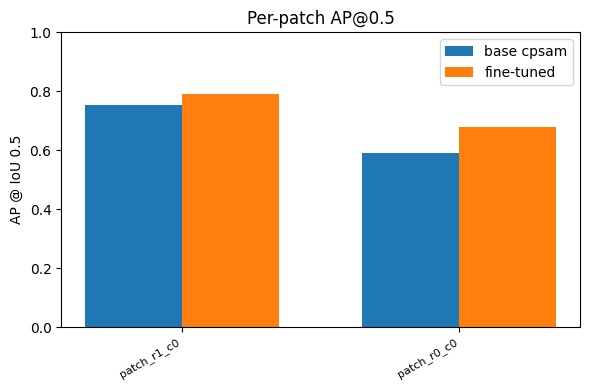

NameError: name 'load_theme' is not defined

In [21]:
ap_base_per = ap_base[:, 0]
ap_ft_per   = ap_ft[:, 0]
names = [p['name'] for p in val_pairs]
x = np.arange(len(names))
w = 0.35

# AP bars
#theme = load_theme(AQUAREL_THEME)
#theme.apply()
fig, ax = plt.subplots(figsize=(max(6, len(names) * 1.2), 4))
ax.bar(x - w/2, ap_base_per, w, label='base cpsam')
ax.bar(x + w/2, ap_ft_per,   w, label='fine-tuned')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('AP @ IoU 0.5')
ax.set_ylim(0, 1)
ax.set_title('Per-patch AP@0.5')
ax.legend()
fig.tight_layout()
plt.savefig(FIG_DIR / '04_ap_bars.png', dpi=150, bbox_inches='tight')
plt.show()
plt.rcdefaults()

# Cell counts
gt   = [int(m.max()) for m in val_masks]
base = [int(m.max()) for m in masks_base_list]
ft   = [int(m.max()) for m in masks_ft_list]
w2 = 0.25

theme = load_theme(AQUAREL_THEME)
theme.apply()
fig, ax = plt.subplots(figsize=(max(6, len(names) * 1.2), 4))
ax.bar(x - w2,   gt,   w2, label='ground truth')
ax.bar(x,        base, w2, label='base cpsam')
ax.bar(x + w2,   ft,   w2, label='fine-tuned')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Cell count')
ax.set_title('Cell count per patch')
ax.legend()
fig.tight_layout()
plt.savefig(FIG_DIR / '04_cell_counts.png', dpi=150, bbox_inches='tight')
plt.show()
plt.rcdefaults()